# AR(p) Parameter Estimation

The $\text{AR}(p)$ process is defined by,

$
\begin{align}
X_t = \sum_{i=1}^p \varphi_i X_{t-i} + \varepsilon_{t}
\end{align}
\tag{1}
$

where,

$
\begin{align}
\varepsilon_t \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{2}
$

The Yule-Walker equations are relate the AR(p) parameters $\varphi_i$ to the autocorrelation function. If zero mean is</br>
assumed it follows that,

$
\begin{align}
\rho_n = \frac{\text{E}[X_t X_{t-n}]}{\text{E}[X_t^2]}
\end{align}
\tag{3}
$

The autocorrelation functions can be shown to have the following properties,

$
\begin{align}
&\rho_0 = 1 \\
&\rho_n \leq 1 \\
&\rho_n = \rho_{-n}
\end{align}
\tag{4}
$

Define the matrices,

$
\begin{align}
\hat{r} =
\begin{bmatrix}
\rho_1 \\
\rho_2 \\
\rho_3 \\
\vdots \\
\rho_{n-1} \\
\rho_{n}
\end{bmatrix}
\end{align}
\tag{5}
$

$
\begin{align}
\hat{\Phi} =
\begin{bmatrix}
\varphi_1 \\
\varphi_2 \\
\varphi_3 \\
\vdots \\
\varphi_{n-1} \\
\varphi_{n}
\end{bmatrix}
\end{align}
\tag{6}
$

$
\begin{align}
\hat{R} =
\begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{n-2} & \rho_{n-1} \\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{n-3} & \rho_{n-2} \\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{n-4} & \rho_{n-3} \\
\vdots & \vdots  & \vdots & \ddots & \vdots & \vdots \\
\rho_{n-2} & \rho_{n-3} & \rho_{n-4} & \cdots & 1 & \rho_1 \\
\rho_{n-1} & \rho_{n-2} & \rho_{n-3} & \cdots & \rho_1 & 1 \\
\end{bmatrix}
\end{align}
\tag{7}
$

Then the Yule-Walker equations are given by,

$
\begin{align}
\hat{\Phi} = \hat{R}^{-1} \hat{r}
\end{align}
\tag{8}
$

## Examples

The Yule-Walker equations for $\text{AR}(1)$ is given by,

$
\begin{align}
\varphi_1 = \rho_1
\end{align}
\tag{9}
$

This is the OLS solution.

For $\text{AR}(2)$,

$
\begin{align}
\varphi_1 &= \frac{\rho_1 - \rho_1 \rho_2}{1 - \rho_1^2} \\
\varphi_2 &= \frac{\rho_2 - \rho_1^2}{1 - \rho_1^2}
\end{align}
\tag{10}
$

## Stationaity

Stationarity of an $\text{AR}(p)$ leads to convergence of the moments as $t \to \infty$. Recall the shift operator, $L$, defined by,

$
\begin{align}
&L X_t = X_{t-1} \\
&L^2 X_t = X_{t-2} \\
&L^3 X_t = X_{t-3} \\
&\vdots
\end{align}
\tag{11}
$

An $\text{AR}(p)$ process can be written as,

$
\begin{align}
\varepsilon_t = (1 - \varphi L - \varphi^2 L^2 - \varphi^3 L^3 - \cdots - \varphi^p L^p) X_t
\end{align}
\tag{12}
$

The characteristic equation is obtained by replacing $L$ with the variable $z$ and setting the result to zero,

$
\begin{align}
1 - \varphi z - \varphi^2 z^2 - \varphi^3 z^3 - \cdots - \varphi^p z^p = 0
\end{align}
\tag{13}
$

Stationarity requires that $\lvert z \rvert > 1$. To see this consider $\text{AR}(1)$. The characteristic equation is,

$
\begin{align}
1 - \varphi z = 0
\end{align}
\tag{14}
$

The solution is $z = \frac{1}{\varphi}$. It follows that stationarity requires,

$
\begin{align}
\lvert \varphi \rvert < 1
\end{align}
\tag{15}
$

## Imports

In [30]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [31]:
nsample = 1000

def comparison_plot(φ_vals, title, ylim, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6), lw=1)
    return t, scan

## Simulations

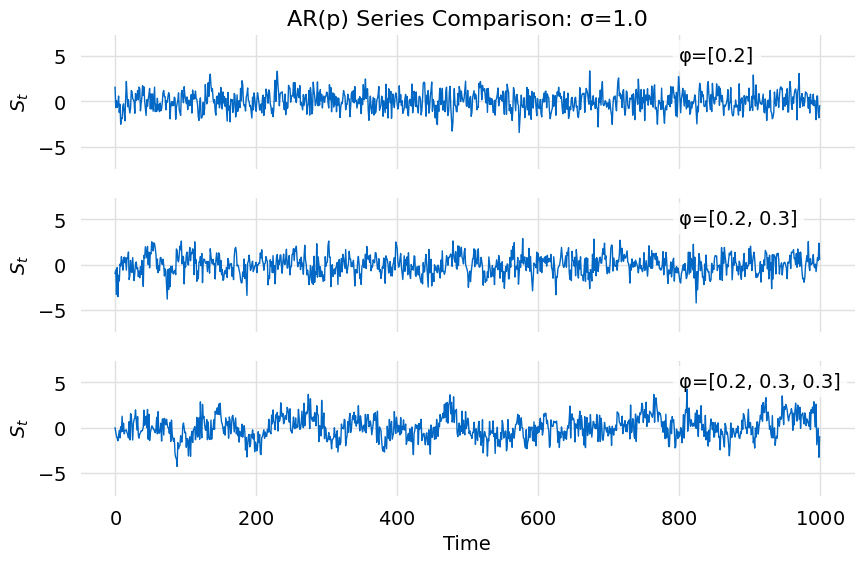

In [32]:
σ = 1.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-7.5, 7.5], *params)

## Estimation of $\text{AR}(p)$ Parameters ($\sigma = 1$)

$\text{AR}(p)$ parameters are estimated using two methods. The Yule-Walker ACF and `statsmodels.tsa.arima_model.ARMA`

### AR(1) Example $\varphi = 0.2$

In [33]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.2037167]))

In [34]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1440.263
Date:                Fri, 24 Nov 2023   AIC                           2886.526
Time:                        14:01:23   BIC                           2901.249
Sample:                             0   HQIC                          2892.122
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0471      0.041      1.160      0.246      -0.032       0.127
ar.L1          0.2040      0.030      6.751      0.000       0.145       0.263
sigma2         1.0435      0.050     20.695      0.000       0.945       1.142
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 3.06
Prob(Q):                              0.84   Prob(JB):                         0.22
Heteroskedasticity (H):               1.09   Skew:                             0.03
Prob(H) (two-sided):                  0.45   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.04709676816091099,
      "err": 0.040585033186635554,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "7dea1a5c-cbdb-4dbf-a4a5-3bd3b66513b7",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.20400833326126566,
         "err": 0.030219890889396372,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "7dea1a5c-cbdb-4dbf-a4a5-3bd3b66513b7",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 1.0435144738339501,
      "err": 0.05042244603759869,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "7dea

### AR(2) Example $\varphi = [0.2, 0.3]$

In [36]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.2081384 , 0.28395483]))

In [37]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1419.519
Date:                Fri, 24 Nov 2023   AIC                           2847.038
Time:                        14:01:24   BIC                           2866.669
Sample:                             0   HQIC                          2854.499
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0476      0.063     -0.756      0.450      -0.171       0.076
ar.L1          0.2080      0.030      6.918      0.000       0.149       0.267
ar.L2          0.2855      0.030      9.524      0.000       0.227       0.344
sigma2         1.0009      0.044     22.810      0.000       0.915       1.087
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 6.31
Prob(Q):                              0.83   Prob(JB):                         0.04
Heteroskedasticity (H):               0.90   Skew:                            -0.18
Prob(H) (two-sided):                  0.36   Kurtosis:                         3.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [38]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": -0.04761239746203204,
      "err": 0.06296096335722945,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "9b8121ef-8385-40af-ae68-440ae931b2a5",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.2080385931407756,
         "err": 0.03007317577958746,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "9b8121ef-8385-40af-ae68-440ae931b2a5",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.2854738649627828,
         "err": 0.029975296270111088,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "es

### AR(3) Example $\varphi = [0.2, 0.3, 0.3]$

In [39]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.20033108, 0.2760018 , 0.27786716]))

In [40]:
result, result_model = arima.compute_ar_estimate(ar[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1420.179
Date:                Fri, 24 Nov 2023   AIC                           2850.359
Time:                        14:01:24   BIC                           2874.898
Sample:                             0   HQIC                          2859.685
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0156      0.130      0.120      0.904      -0.239       0.271
ar.L1          0.1981      0.031      6.492      0.000       0.138       0.258
ar.L2          0.2785      0.030      9.191      0.000       0.219       0.338
ar.L3          0.2797      0.032      8.811      0.000       0.217       0.342
sigma2         1.0017      0.047     21.488      0.000       0.910       1.093
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.87
Prob(Q):                              0.94   Prob(JB):                         0.65
Heteroskedasticity (H):               1.05   Skew:                            -0.01
Prob(H) (two-sided):                  0.65   Kurtosis:                         2.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [41]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.015634180975015625,
      "err": 0.13014379933426273,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "1f0c5aaf-4348-4ab5-9773-cf7a2fa53fe9",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.1981406083694942,
         "err": 0.030520263689855383,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "1f0c5aaf-4348-4ab5-9773-cf7a2fa53fe9",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.27845884025012846,
         "err": 0.030298431519866203,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "

## Simulations $\sigma = 5.0$

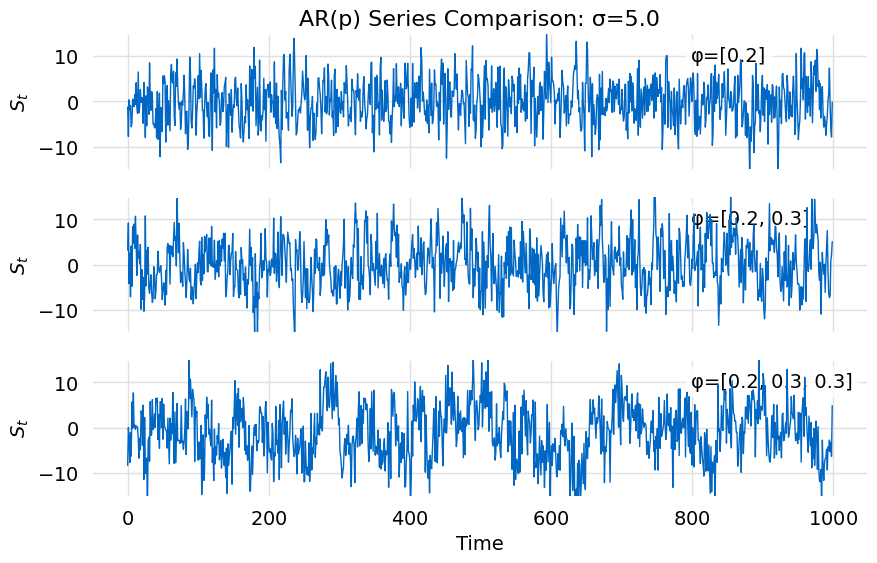

In [42]:
σ = 5.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-15.0, 15.0], *params)

### AR(1) Example ($\varphi = 0.2$)

In [43]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.19327535]))

In [44]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2999.666
Date:                Fri, 24 Nov 2023   AIC                           6005.332
Time:                        14:01:24   BIC                           6020.056
Sample:                             0   HQIC                          6010.928
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0972      0.190      0.510      0.610      -0.276       0.470
ar.L1          0.1931      0.030      6.516      0.000       0.135       0.251
sigma2        23.6039      1.118     21.118      0.000      21.413      25.795
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.94
Prob(Q):                              0.91   Prob(JB):                         0.38
Heteroskedasticity (H):               0.98   Skew:                             0.00
Prob(H) (two-sided):                  0.87   Kurtosis:                         2.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [45]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.09720039533998358,
      "err": 0.19044605004259052,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "6446be92-786e-4533-811d-a6d1b1528aca",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.19310208086697941,
         "err": 0.029636776379329356,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "6446be92-786e-4533-811d-a6d1b1528aca",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 23.603935262758984,
      "err": 1.1176941012924009,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "6446be

### AR(2) Example ($\varphi = [0.2, 0.3]$)

In [46]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.25266424, 0.26260895]))

In [47]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -3035.855
Date:                Fri, 24 Nov 2023   AIC                           6079.711
Time:                        14:01:25   BIC                           6099.342
Sample:                             0   HQIC                          6087.172
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2140      0.330      0.648      0.517      -0.433       0.861
ar.L1          0.2526      0.031      8.260      0.000       0.193       0.312
ar.L2          0.2633      0.031      8.538      0.000       0.203       0.324
sigma2        25.3711      1.174     21.609      0.000      23.070      27.672
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 3.33
Prob(Q):                              0.79   Prob(JB):                         0.19
Heteroskedasticity (H):               1.23   Skew:                             0.13
Prob(H) (two-sided):                  0.06   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [48]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.21395943510670112,
      "err": 0.3301209275983168,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "03ed4b75-9d50-46ee-9d4d-f766b710983c",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.2525554479789841,
         "err": 0.03057684884621501,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "03ed4b75-9d50-46ee-9d4d-f766b710983c",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.26333169092405756,
         "err": 0.03084377731379511,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_

### AR(3) Example ($\varphi = [0.2, 0.3, 0.3]$)

In [49]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.17224942, 0.25073927, 0.3193785 ]))

In [50]:
result, result_model = arima.compute_ar_estimate(ar[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -3035.355
Date:                Fri, 24 Nov 2023   AIC                           6080.711
Time:                        14:01:25   BIC                           6105.250
Sample:                             0   HQIC                          6090.037
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2128      0.320      0.664      0.507      -0.415       0.841
ar.L1          0.2609      0.031      8.303      0.000       0.199       0.323
ar.L2          0.2714      0.032      8.527      0.000       0.209       0.334
ar.L3         -0.0317      0.032     -0.977      0.328      -0.095       0.032
sigma2        25.3444      1.173     21.598      0.000      23.044      27.644
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 3.12
Prob(Q):                              0.95   Prob(JB):                         0.21
Heteroskedasticity (H):               1.24   Skew:                             0.12
Prob(H) (two-sided):                  0.05   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [51]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.2127988510923091,
      "err": 0.3204784397580063,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "c7fa0b3b-1cd0-46cd-9a1b-5c7e2395ef72",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.26090866750058994,
         "err": 0.03142489735228906,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c7fa0b3b-1cd0-46cd-9a1b-5c7e2395ef72",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.27136985647472384,
         "err": 0.03182586291888329,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_